In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 슬롯머신(Bandit) 구현
class Bandit:
  def __init__(self, arms=10):
    self.rates = np.random.rand(arms)

  def play(self, arm):
    rate = self.rates[arm]
    if rate > np.random.rand():
      return 1
    else:
      return 0

In [6]:
# 에이전트 구현(엡실론-탐욕 정책 활용)
class Agent:
  def __init__(self, epsilon, action_size=10):
    self.epsilon = epsilon
    self.Qs = np.zeros(action_size)
    self.ns = np.zeros(action_size)

  def update(self, action, reward):
    self.ns[action] += 1
    self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

  def get_action(self):
    if np.random.rand() < self.epsilon:
      return np.random.randint(0, len(self.Qs))
    else:
      return np.argmax(self.Qs)

In [7]:
runs = 200
steps = 1000
epsilon = 0.1
all_rates = np.zeros((runs, steps))  # (200, 1000) 형상 배엻

for run in range(runs):
  bandit = Bandit()
  agent = Agent(epsilon)
  total_reward = 0
  rates = []

  for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)
    total_reward += reward
    rates.append(total_reward / (step + 1))

  all_rates[run] = rates  # 보상 결과 기록

avg_rates = np.average(all_rates, axis=0)  # 각 단계의 평균 저장

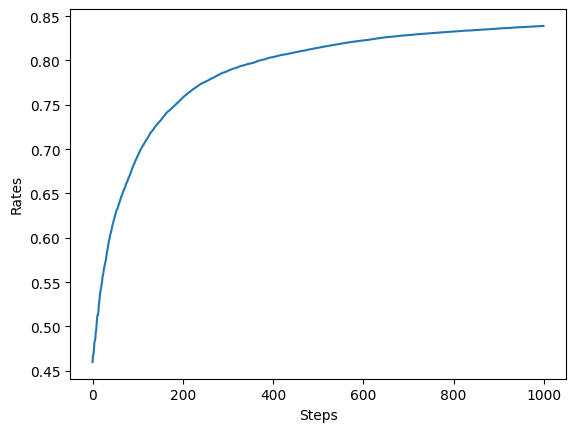

In [8]:
# 그래프 그리기: 단계별 승률(200번 실험 후 평균)
plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(avg_rates)
plt.show()

In [10]:
runs = 200
steps = 1000
epsilons = [0.1, 0.3, 0.01]
avg_rates = {}
all_rates = np.zeros((runs, steps))  # (200, 1000) 형상 배엻
for e in range(len(epsilons)):
  epsilon = epsilons[e]

  for run in range(runs):
    bandit = Bandit()
    agent = Agent(epsilon)
    total_reward = 0
    rates = []

    for step in range(steps):
      action = agent.get_action()
      reward = bandit.play(action)
      agent.update(action, reward)
      total_reward += reward
      rates.append(total_reward / (step + 1))

    all_rates[run] = rates  # 보상 결과 기록

  avg_rates[e] = np.average(all_rates, axis=0)  # 각 단계의 평균 저장

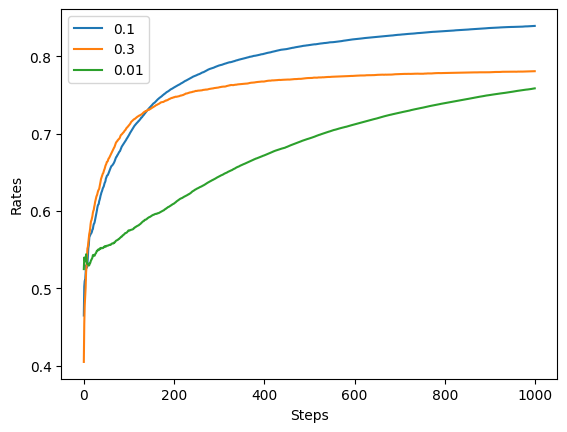

In [14]:
# 그래프 그리기: 단계별 승률(200번 실험 후 평균)
plt.ylabel('Rates')
plt.xlabel('Steps')
for i in range(len(epsilons)):
  plt.plot(avg_rates[i], "-", label=epsilons[i])
plt.legend(loc='best')
plt.show()